In [ ]:
!apt-get update
!apt-get install -y libopencv-dev build-essential cmake

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Get:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Get:9 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:10 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,877 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:13 https://ppa.launchpadcontent.net/d

In [ ]:
%%writefile main.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>

int main() {
    std::cout << "--- Sistem Bilgileri ---" << std::endl;
    std::cout << "OpenCV Versiyonu: " << CV_VERSION << std::endl;

    int deviceCount = 0;
    cudaError_t error = cudaGetDeviceCount(&deviceCount);

    if (error == cudaSuccess && deviceCount > 0) {
        std::cout << "CUDA Durumu: Başarılı! Colab GPU Algılandı." << std::endl;
        std::cout << "Algılanan GPU Sayısı: " << deviceCount << std::endl;
    } else {
        std::cout << "CUDA Durumu: Cihaz bulunamadı veya GPU aktif değil!" << std::endl;
    }

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4` -I/usr/local/cuda/include -L/usr/local/cuda/lib64 -lcudart
!./app

--- Sistem Bilgileri ---
OpenCV Versiyonu: 4.6.0
CUDA Durumu: Başarılı! Colab GPU Algılandı.
Algılanan GPU Sayısı: 1


In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [27]:
image_path = '/content/image1.jpg (1).jpeg'

# Resmi oku
original_img = cv2.imread(image_path)

if original_img is None:
    print(f"Hata: Resim '{image_path}' yüklenemedi. Lütfen yolun doğru olduğundan ve dosyanın mevcut olduğundan emin olun.")
else:
    # Resmi gri tonlamaya çevir (eğer renkliyse)
    # Parlaklık işlemleri genellikle tek kanallı görüntülerde daha anlamlıdır.
    if len(original_img.shape) == 3:
        img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
        print("Resim başarıyla yüklendi ve gri tonlamaya çevrildi.")
    else:
        img = original_img
        print("Resim başarıyla yüklendi (zaten gri tonlamalı).")


Resim başarıyla yüklendi ve gri tonlamaya çevrildi.


### Tek Kanallı Resim Parlaklık Azaltma

Resmin parlaklık değerlerini (0-255 arası) yarıya ve çeyreğe düşürerek görsel etkilerini inceleyelim.

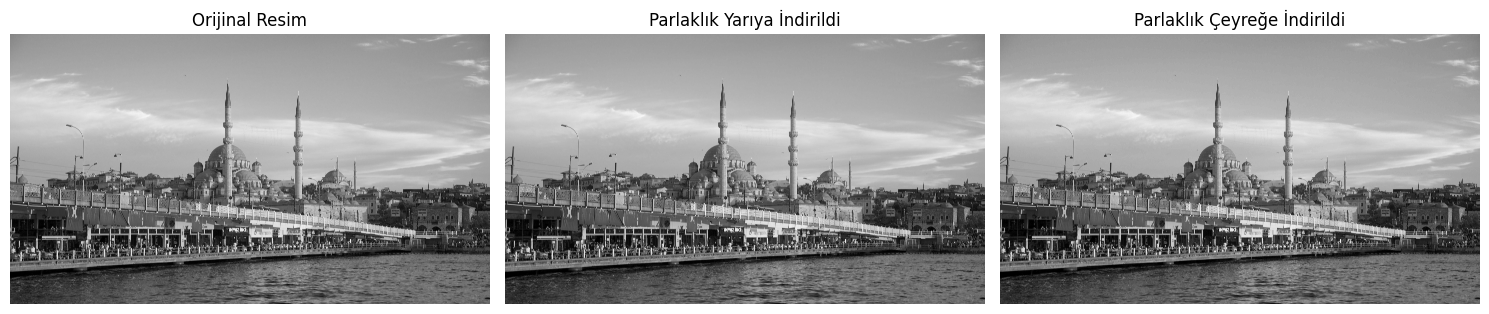

In [26]:
# Orijinal tek kanallı resmi göster
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Orijinal Resim')
plt.axis('off')

# Parlaklığı yarıya düşür
# uint8 formatında olduğu için doğrudan bölme yaparsak sorun yaşayabiliriz. Float'a çevirip sonra tekrar uint8'e dönüştürelim.
img_half_brightness = (img / 2).astype(np.uint8)
plt.subplot(1, 3, 2)
plt.imshow(img_half_brightness, cmap='gray')
plt.title('Parlaklık Yarıya İndirildi')
plt.axis('off')

# Parlaklığı çeyreğe düşür
img_quarter_brightness = (img / 4).astype(np.uint8)
plt.subplot(1, 3, 3)
plt.imshow(img_quarter_brightness, cmap='gray')
plt.title('Parlaklık Çeyreğe İndirildi')
plt.axis('off')

plt.tight_layout()
plt.show()